# Example spectrum

Calculating cross-section
Calculating cross-section


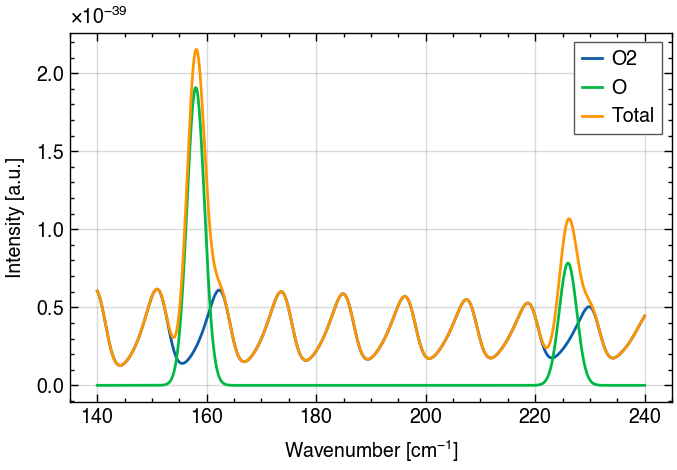

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from ramlab.molecules import N2, O2, O
from ramlab.simulate.combine import CombinedMolecule
from ramlab.simulate import RawSimulationMethod, RawBinnedSimulationMethod, Subsampled
from ramlab.simulate.linespreadfunction import Voigt, Hubbert
import wedme.apply.dev as _ # Optional, comment if not installed

# Define a simulation grid. If fitting experimental data, this should be the same as the experimental grid.
dnu_sim = np.linspace(140, 240, 1000)

# Define the molecules to be simulated
combined = CombinedMolecule(
    # N2 = (N2, N2.get_all_transitions(laser_wavelength=532e-9).filter(dv=0)),
    O2 = (O2, O2.get_all_transitions(laser_wavelength=532e-9).filter(dv=0)),
    O = (O, O.get_all_transitions(laser_wavelength=532e-9)) # THe absolute value of the O cross-section is currently wrong.
)
# Define their mole fractions
X = {
    # 'N2': 0.8,
    'O2': 1,
    'O': 3.5
}
T_sim = 3800  # Temperature in Kelvin
# Define the lineshape function to be used in the simulation
lineshape = Voigt(w_g=1.6, w_l=0)

# Define the simulation method. 
# RawBinnedSimulationMethod is used for sub-sampling a spectrum and binning it to a specified grid.
# This has much better performance when linewidth ~< pixel size.
simulation = RawBinnedSimulationMethod(N_bin=1)

plt.figure()
# Simulate the contributions of each molecule
for m, (dnu_stick, _, I_stick) in combined.contributions(T=T_sim, **X).items():
    I_sim = simulation.simulate(
        dnu_sim, dnu_stick, I_stick, lineshape
    )
    plt.plot(dnu_sim, I_sim, label=f"{m}")

# Or simulate the total intensity like you would do in a fit.
# This is equivalent to the above, but combines the contributions internally.
dnu_stick, _, I_stick = combined.stick(T=T_sim, **X)
I_tot = simulation.simulate(
    dnu_sim, dnu_stick, I_stick, lineshape
)
plt.plot(dnu_sim, I_tot, label="Total")

plt.xlabel("Wavenumber [cm$^{-1}$]")
plt.legend()
plt.ylabel("Intensity [a.u.]")
plt.show()

# Load the data

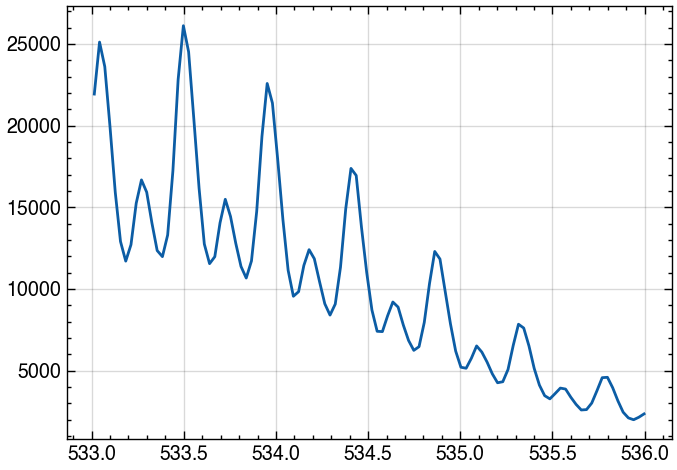

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from toddler.data.spectrum import Spectrum
import wedme
from pathlib import Path
import os
from labctl.experiments import SimpleLaserExperiment

wedme.dev()

f_base = Path(os.path.abspath(""))
# s_sig = Spectrum.from_sif(f_base / "spectrum_air_roomtemp_sig.sif").median(axis=2).squeeze()
# s_bg = Spectrum.from_sif(f_base / "spectrum_air_roomtemp_bg.sif").median(axis=2).squeeze()


f_base = f_base / "N2"
f_comb = f_base / "N2_300mbar_20um_roomtemp_rot.sif"
# f_comb = f_base / "02_607nm_N2 gas_10slm_300mbar_20um_1s.sif"
_, _, s = SimpleLaserExperiment.postprocess(f_comb, f_base / "idx.pkl")

s = s.slice(533e-9, 536e-9)
plt.figure()
plt.plot(s.lambdanm, s.sdata, label="Spectrum")
# plt.xlim(532, 540)
plt.show()

# Fit

In [3]:
from ramlab.molecules import N2, O2
import numpy as np
from ramlab.fit import MultiMoleculeFitRecipe
from ramlab.molecules.polarisation import Polarisation
from ramlab.simulate.linespreadfunction import Voigt, Hubbert
from ramlab.fit.modifiers import WavelengthAxisCorrection, MeasurementSpectrum
from ramlab.simulate.raw import RawSimulationMethod, RawBinnedSimulationMethod

# Put some a-priori guesses for the fit parameters
lineshape=Voigt(w_g = 0.041, w_l = 0.046, vary_g=True, vary_l=True) 
# lineshape=Hubbert(w=0.01, q=0.1, vary_q = True, vary_w = True) 
wavelength_correction = WavelengthAxisCorrection(1, initial_values=[0.635, 0], vary_wl=True)
# wavelength_correction = WavelengthAxisCorrection(1, initial_values=[0.569, 2.435 ], vary_wl=True)

fit = MultiMoleculeFitRecipe(
    molecules=[ # List of molecules to fit
        # (N2, N2.get_all_transitions(laser_wavelength=532e-9).filter(dv=1)),
        (N2, N2.get_all_transitions(laser_wavelength=532e-9).filter(dv=0, dJ=2)),
        # (O2, O2.get_all_transitions(laser_wavelength=532e-9).filter(dv=0, dJ=2)), #
               ],
    polarisation=Polarisation.COMBINED,
    lineshape=lineshape,
    meas_modifiers=[
        wavelength_correction,
    ],
    simulation_method=RawBinnedSimulationMethod(N_bin=4),
)

def test(params):
    for x in params.keys():
        print(f"{x:20s} = {params[x].value:.3f} {'(fixed)' if not params[x].vary else ''}")

# Fit one of the spectra that has great signal
fit.prepare()
fit.fitparameters['T'].value = 300
fit.fitparameters['T'].vary = False
fit.fitparameters['X_N2'].vary = False
fit.fitparameters['X_N2'].value = 1
# fit.fitparameters['X_O2'].vary = False
# fit.fitparameters['X_O2'].value = 0.2
# fit.make(fit.fitparameters, meas=s)
test(fit.fitparameters)
fitresults = fit.fit(MeasurementSpectrum(s))
# Apply the resulting fit parameters (lineshape, wavelength correction) to the other spectra

fit.apply_parameters(fitresults.fit_params, 
                     vary_l           =False, vary_g=False, vary_w=False, vary_q=False, # Fix the linewidths
                     vary_wl=False # Fix the wavelength correction of everything other than 0th order
                     )

fit.prepare()
fit.fitparameters['T'].value = 300
fit.fitparameters['T'].vary = False
fitresults = fit.fit(MeasurementSpectrum(s))
test(fitresults.fit_params)

Calculating cross-section
A                    = 1.000 
T                    = 300.000 (fixed)
X_N2                 = 1.000 (fixed)
w_g                  = 0.041 
w_l                  = 0.046 
lambda_correction_0  = 0.635 
lambda_correction_1  = 0.000 
A                    = 1.019 
T                    = 300.000 (fixed)
X_N2                 = 0.317 
w_g                  = 0.018 (fixed)
w_l                  = 0.071 (fixed)
lambda_correction_0  = 0.635 (fixed)
lambda_correction_1  = -0.009 (fixed)


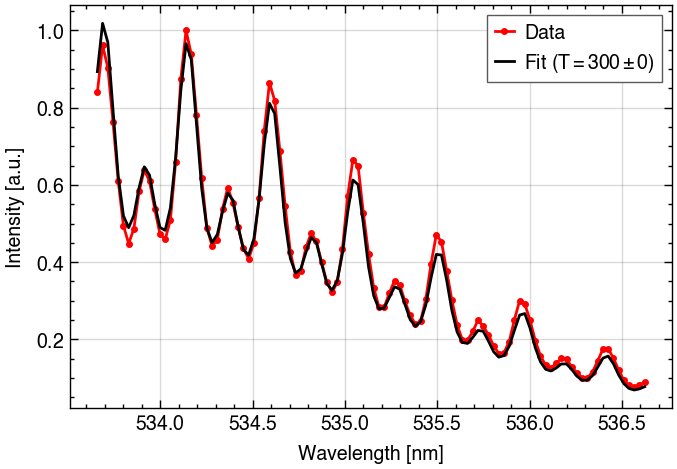

In [4]:
import matplotlib.pyplot as plt
import wedme
from ramlab.display import plot_results

# Plot the fit
wedme.figure.dev()
plot_results(fitresults)
plt.show()

# Fit other measurements
Now that the calibration (lineshape, wavelength correction) is determined, we can apply it to the other spectra.

In [5]:
# f_comb = f_base / "05_607nm_N2 plasma_10slm_300mbar_400W_50um_20s.sif"
# _, _, s_next = SimpleLaserExperiment.postprocess(f_comb, f_base / "labctl" / "09_center_20s_idx.pkl")


f_comb = f_base / "03_546nm_N2 plasma_10slm_300mbar_400W_20um_20s.sif"
_, _, s_next = SimpleLaserExperiment.postprocess(f_comb, f_base / "labctl" / "09_center_20s_idx.pkl")
# s = s.slice(533e-9)

fit.prepare()
fitresults = fit.fit(MeasurementSpectrum(s_next))

wedme.figure.dev()
plot_results(fitresults)
plt.show()

KeyboardInterrupt: 